In [2]:
import os
import glob

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from matplotlib import pyplot as plt
import open3d as o3d
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix
import pandas as pd
from joblib import Parallel, delayed
import random
tf.random.set_seed(1234)

c:\Users\spaudel\AppData\Local\anaconda3\envs\tf-gpu\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [3]:
DIR = r"D:\CVPR_Data\New_PLY\Day1_1"
print(len(os.listdir(DIR)))

19


In [ ]:
STABLE_LIST = ['419', '453', '458', '467', '472', '485', '492', '495', '542-533']
# Re-map to continuous indices

CLASS_TO_SOW = {sow: idx for idx, sow in enumerate(STABLE_LIST)}

NUM_POINTS = 1500

N_JOBS = 22

MAX_FILES_PER_CLASS = 500

MIN_SAMPLES_PER_CLASS = 20

# ✅ NEW: skip reading files smaller than 500 KB

MIN_FILE_KB = 100

MIN_FILE_BYTES = MIN_FILE_KB * 1024

print(f"Verified {len(CLASS_TO_SOW)} stable pigs for analysis.")


Verified 9 stable pigs for analysis.


In [5]:



# ============================================================

# PROCESS ONE PLY FILE

# ============================================================

def process_one_file(full_path, label_index):

    try:

        # ✅ Fast pre-check: skip tiny files without reading them

        try:

            if os.path.getsize(full_path) < MIN_FILE_BYTES:

                return None, None

        except OSError:

            return None, None



        pcd = o3d.io.read_point_cloud(full_path)

        pcd = pcd.voxel_down_sample(voxel_size=0.005)



        pts = np.asarray(pcd.points)

        n_pts = pts.shape[0]



        if n_pts < NUM_POINTS:

            return None, None



        # 1) Random sampling to fixed size

        idx = np.random.choice(n_pts, NUM_POINTS, replace=False)

        sampled = pts[idx]



        # 2) Unit sphere normalization

        centroid = np.mean(sampled, axis=0)

        sampled = sampled - centroid

        dist = np.max(np.sqrt(np.sum(sampled**2, axis=1)))

        if dist > 0:

            sampled = sampled / dist



        return sampled, label_index



    except Exception:

        return None, None



# ============================================================

# DATASET PARSER

# ============================================================

def parse_dataset_parallel(DIR):

    available_folders = [f for f in os.listdir(DIR) if f in CLASS_TO_SOW]



    print(f"\nTargeting {len(CLASS_TO_SOW)} stable pigs.")

    print(f"Found {len(available_folders)} folders in directory.")



    jobs = []

    for label_folder in available_folders:

        label_idx = CLASS_TO_SOW[label_folder]

        folder_path = os.path.join(DIR, label_folder)



        all_files = []

        for root, _, files in os.walk(folder_path):

            for f in files:

                if f.lower().endswith(".ply"):

                    full = os.path.join(root, f)



                    # ✅ Skip small files at collection time too (fewer jobs scheduled)

                    try:

                        if os.path.getsize(full) < MIN_FILE_BYTES:

                            continue

                    except OSError:

                        continue



                    all_files.append(full)



        # Sample files per class

        if len(all_files) > MAX_FILES_PER_CLASS:

            selected_files = random.sample(all_files, MAX_FILES_PER_CLASS)

        else:

            selected_files = all_files



        for f in selected_files:

            jobs.append((f, label_idx))



    print(f"Total files scheduled (>= {MIN_FILE_KB} KB): {len(jobs)}")



    results = Parallel(n_jobs=N_JOBS, prefer="processes")(

        delayed(process_one_file)(path, lbl) for path, lbl in jobs

    )



    final_points, final_labels = [], []

    for sample, label in results:

        if sample is not None:

            final_points.append(sample)

            final_labels.append(label)



    if len(final_points) == 0:

        print("❌ No usable samples found!")

        return [None] * 4



    data_points = np.array(final_points)

    data_labels = to_categorical(np.array(final_labels), num_classes=len(CLASS_TO_SOW))



    # ============================================================

    # TRAIN/VAL SPLIT

    # ============================================================

    train_pts, val_pts, train_lbl, val_lbl = train_test_split(

        data_points, data_labels, test_size=0.2, random_state=42, stratify=final_labels

    )



    print(f"\nFinal Stable Dataset Shapes ({len(CLASS_TO_SOW)} Classes):")

    print(f"Train: {train_pts.shape}, Val: {val_pts.shape}")



    return train_pts, train_lbl, val_pts, val_lbl

In [6]:
train_points, train_labels, test_points, test_labels = parse_dataset_parallel(DIR)


Targeting 9 stable pigs.
Found 9 folders in directory.
Total files scheduled (>= 200 KB): 4500

Final Stable Dataset Shapes (9 Classes):
Train: (3600, 1500, 3), Val: (900, 1500, 3)


In [7]:


# Convert one-hot labels back to integer class IDs
train_cls = np.argmax(train_labels, axis=1)
test_cls  = np.argmax(test_labels, axis=1)

# Combine all samples
all_cls = np.concatenate([train_cls, test_cls])

# Count per class
unique, counts = np.unique(all_cls, return_counts=True)
class_counts = dict(zip(unique, counts))

print("\n===== Sample Counts Per Class =====")
for cls, cnt in class_counts.items():
    print(f"Class {cls}: {cnt}")

# Summary statistics
counts_array = counts.astype(np.int32)

print("\n===== Label Count Statistics =====")
print(f"Total samples: {counts_array.sum()}")
print(f"Mean per class: {counts_array.mean():.2f}")
print(f"Std per class: {counts_array.std():.2f}")

# Top 5 most represented classes
print("\nTop 5 classes (largest sample counts):")
for cls, cnt in sorted(class_counts.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"Class {cls}: {cnt}")

# Bottom 5 least represented classes
print("\nBottom 5 classes (smallest sample counts):")
for cls, cnt in sorted(class_counts.items(), key=lambda x: x[1])[:5]:
    print(f"Class {cls}: {cnt}")




===== Sample Counts Per Class =====
Class 0: 500
Class 1: 500
Class 2: 500
Class 3: 500
Class 4: 500
Class 5: 500
Class 6: 500
Class 7: 500
Class 8: 500

===== Label Count Statistics =====
Total samples: 4500
Mean per class: 500.00
Std per class: 0.00

Top 5 classes (largest sample counts):
Class 0: 500
Class 1: 500
Class 2: 500
Class 3: 500
Class 4: 500

Bottom 5 classes (smallest sample counts):
Class 0: 500
Class 1: 500
Class 2: 500
Class 3: 500
Class 4: 500


In [8]:
def augment(points, label):
    points = tf.cast(points, tf.float32)            # ensure float32
    noise = tf.random.normal(tf.shape(points), mean=0.0, stddev=0.005, dtype=points.dtype)
    points = points + noise
    points = tf.random.shuffle(points)
    return points, label


In [9]:

num_classes = train_labels.shape[1]
print(num_classes)

train_dataset = tf.data.Dataset.from_tensor_slices((train_points, train_labels))
test_dataset = tf.data.Dataset.from_tensor_slices((test_points, test_labels))
train_dataset = train_dataset.shuffle(len(train_points)).map(augment).batch(32)
test_dataset = test_dataset.shuffle(len(test_points)).batch(32)


9


In [10]:
def conv_bn(x, filters):
    x = layers.Conv1D(filters, kernel_size=1, padding="valid")(x)
    x = layers.BatchNormalization(momentum=0.0)(x)
    return layers.Activation("relu")(x)


def dense_bn(x, filters):
    x = layers.Dense(filters)(x)
    x = layers.BatchNormalization(momentum=0.0)(x)
    return layers.Activation("relu")(x)

In [11]:
class OrthogonalRegularizer(keras.regularizers.Regularizer):
    def __init__(self, num_features, l2reg=0.001):
        self.num_features = num_features
        self.l2reg = l2reg
        self.eye = tf.eye(num_features)

    def __call__(self, x):
        x = tf.reshape(x, (-1, self.num_features, self.num_features))
        xxt = tf.tensordot(x, x, axes=(2, 2))
        xxt = tf.reshape(xxt, (-1, self.num_features, self.num_features))
        return tf.reduce_sum(self.l2reg * tf.square(xxt - self.eye))

In [12]:
def tnet(inputs, num_features):

    # Initalise bias as the indentity matrix
    bias = keras.initializers.Constant(np.eye(num_features).flatten())
    reg = OrthogonalRegularizer(num_features)

    x = conv_bn(inputs, 32)
    x = conv_bn(x, 64)
    x = conv_bn(x, 512)
    x = layers.GlobalMaxPooling1D()(x)
    x = dense_bn(x, 256)
    x = dense_bn(x, 128)
    x = layers.Dense(
        num_features * num_features,
        kernel_initializer="zeros",
        bias_initializer=bias,
        activity_regularizer=reg,
    )(x)
    feat_T = layers.Reshape((num_features, num_features))(x)
    # Apply affine transformation to input features
    return layers.Dot(axes=(2, 1))([inputs, feat_T])

In [14]:
inputs = keras.Input(shape=(1500, 3))

x = tnet(inputs, 3)
x = conv_bn(x, 32)
x = conv_bn(x, 64)
x = tnet(x, 64)
x = conv_bn(x, 128)
x = conv_bn(x, 128)
x = conv_bn(x, 256)


feature_layer = x   # <<<<<< HERE

x = layers.GlobalMaxPooling1D()(x)
x = dense_bn(x, 128)
x = layers.Dropout(0.1)(x)
x = dense_bn(x, 128)
x = layers.Dropout(0.1)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs=inputs, outputs=outputs)


In [15]:

initial_learning_rate = 0.001
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate,
    decay_steps=10000,
    decay_rate=0.5,
    staircase=True
)

model.compile(
    loss="categorical_crossentropy",
    optimizer=keras.optimizers.Adam(learning_rate=lr_schedule),
    metrics=["categorical_accuracy"],
)

early_stop_cb = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0,
    patience=25,
    restore_best_weights=True,
)

history = model.fit(
    train_dataset,
    epochs=200,
    validation_data=test_dataset,
    callbacks=[early_stop_cb],
)


Epoch 1/200
113/113 [==============================] - 14s 88ms/step - loss: 3.7429 - categorical_accuracy: 0.5800 - val_loss: 3.3115 - val_categorical_accuracy: 0.6867
Epoch 2/200
113/113 [==============================] - 9s 84ms/step - loss: 3.0999 - categorical_accuracy: 0.7061 - val_loss: 3.1823 - val_categorical_accuracy: 0.7556
Epoch 3/200
113/113 [==============================] - 9s 84ms/step - loss: 2.8811 - categorical_accuracy: 0.7736 - val_loss: 2.9043 - val_categorical_accuracy: 0.7800
Epoch 4/200
113/113 [==============================] - 9s 84ms/step - loss: 2.8654 - categorical_accuracy: 0.7739 - val_loss: 2.9973 - val_categorical_accuracy: 0.7200
Epoch 5/200
113/113 [==============================] - 10s 84ms/step - loss: 2.7529 - categorical_accuracy: 0.8108 - val_loss: 2.7557 - val_categorical_accuracy: 0.8078
Epoch 6/200
113/113 [==============================] - 10s 84ms/step - loss: 2.7146 - categorical_accuracy: 0.8222 - val_loss: 2.5916 - val_categorical_accura

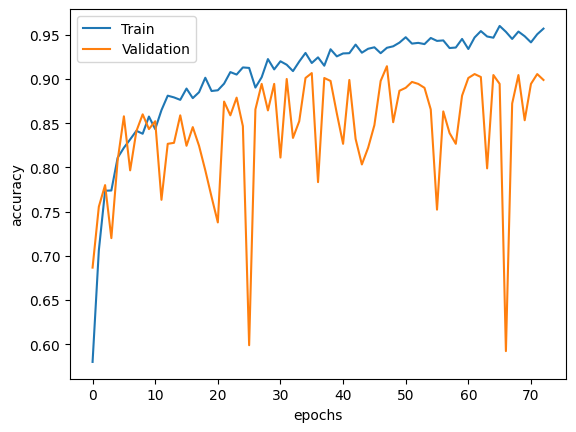

In [16]:
# from matplotlib import pyplot as plt
plt.plot(history.history['categorical_accuracy'])
plt.plot(history.history['val_categorical_accuracy'])
# plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epochs')
plt.legend(['Train', 'Validation'], loc='upper left')
# plt.savefig('learning_curvepng')

1/1 [==============================] - 0s 417ms/step


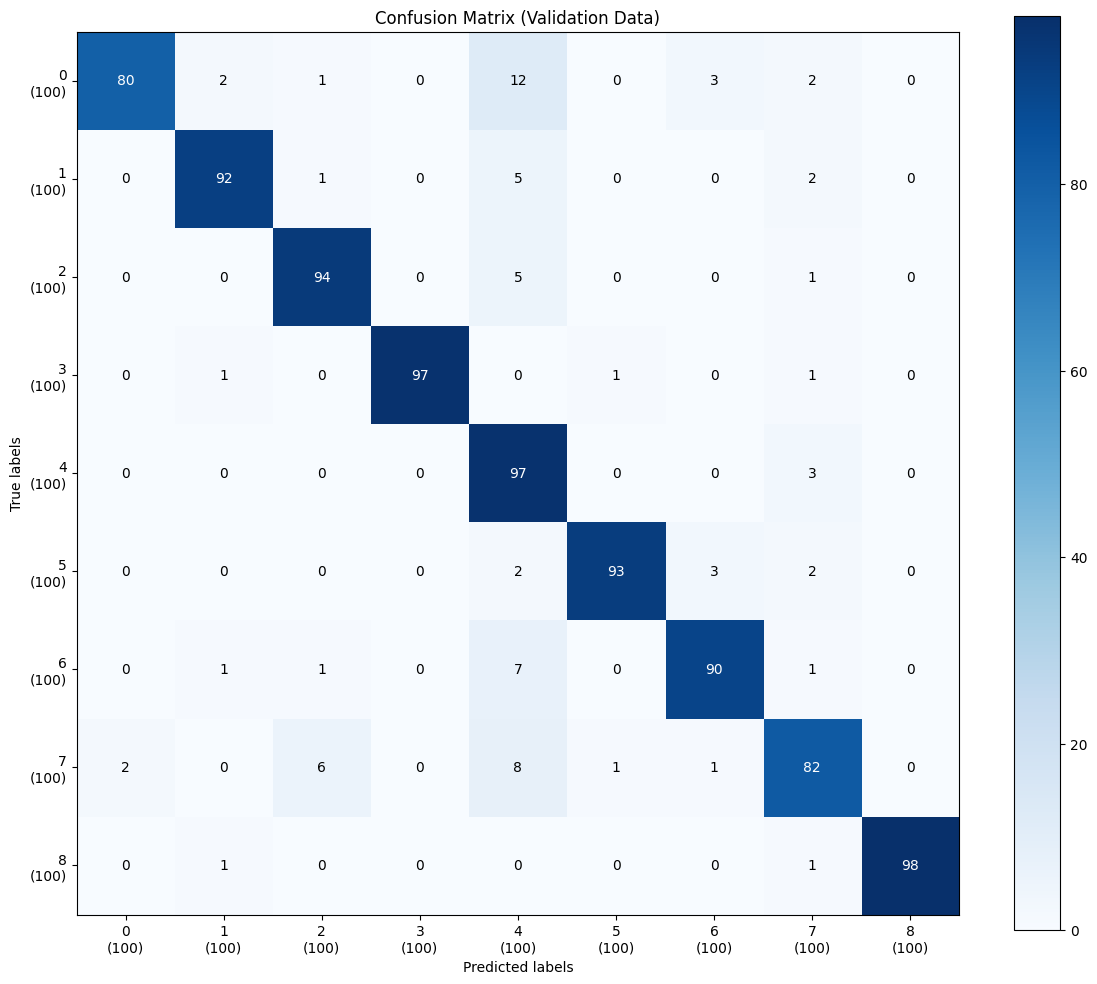

In [17]:
preds = []
true_labels = []
for val_batch, val_label_batch in test_dataset:
    pred_batch = model.predict(val_batch)
    preds.extend(np.argmax(pred_batch, axis=-1))
    true_labels.extend(np.argmax(val_label_batch, axis=-1))

# Convert lists to numpy arrays
preds = np.array(preds)
true_labels = np.array(true_labels)

# Calculate confusion matrix
cm = confusion_matrix(true_labels, preds)

# Calculate total number of images for each class
class_counts = np.sum(cm, axis=1)
num_classes = len(class_counts)  # Get the number of classes from class_counts

# Plot confusion matrix with class counts as tick labels
plt.figure(figsize=(12, 10))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix (Validation Data)')
plt.colorbar()
tick_marks = np.arange(num_classes)
plt.xticks(tick_marks, [f'{i}\n({count})' for i, count in enumerate(class_counts)])
plt.yticks(tick_marks, [f'{i}\n({count})' for i, count in enumerate(class_counts)])

# Annotate confusion matrix cells with counts
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, "{:d}".format(cm[i, j]),
                 ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.ylabel('True labels')
plt.xlabel('Predicted labels')
plt.tight_layout()
plt.show()

In [ ]:
model.save_weights(r"C:\Users\spaudel\OneDrive - University of Arkansas System Division of Agriculture\Desktop\Projects_shivapdl\ID_Organized_CVPR\Weights\Weight_9_2\9pig_Day1_1500.h5)